##### <p style="text-align: center;"> ![alt text](./utilities/cilss.png)</p>
# <p style="text-align: center;">AGHRYMET RCC-WAS</p>
#### &copy; Mandela HOUNGNIBO 2024 (Find more [here](https://github.com/hmandela))

## Library

In [1]:
from wass2s import *
import importlib
from pathlib import Path
import warnings
import gc
warnings.filterwarnings("ignore")

#### Set forecast working directory

In [2]:
# Set forecast working directory
dir_s2s = "./Agro_PRESASS_2025"

In [3]:
dir_s2s = Path(dir_s2s)
os.makedirs(dir_s2s, exist_ok=True)
### Save consolidated results
hdcst_consolidated = {}
fcst_consolidated = {}
scores_consolidated = {}
### Save score
dir_save_score = f"{dir_s2s}/scores"
os.makedirs(dir_save_score, exist_ok=True)
### Save forecasts
dir_to_forecast = f"{dir_s2s}/forecasts"
os.makedirs(dir_to_forecast, exist_ok=True)

#### Set Climatological Years

In [4]:
# Set Climatological Years
clim_year_start = 1994 #1991
clim_year_end = 2016 #2020
dist_method = "nonparam" # "gamma", "t", "lognormal", "normal", "nonparam"
fcst_labels = ["Short", "Near-Normal", "Long"]

## Download Observation and Process 


#### Load Downloader 

In [41]:
# Load WAS_S2S downloader class
downloader = WAS_Download()

In [42]:
# Filter observation names to identify precipitation-related models
variables_obs = [key for key in downloader.AgroObsName().keys() if "PRCP" in key]

# Specify the directory to save downloaded model data
dir_to_save_Obs = f"{dir_s2s}/Observation"

# Define the observation period (years 1993 to 2016)
year_start = 1991
year_end = 2024

# Set the bounding box for the area of interest (latitude and longitude bounds)
extent_obs = [21, -18, 7, 25]   # [Northern, Western, Southern and Eastern] 

# Specify whether to overwrite existing files when downloading data
force_download = False

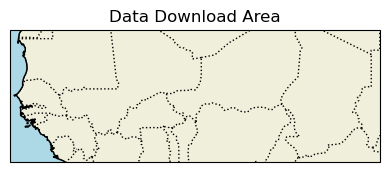

In [43]:
plot_map([extent_obs[1],extent_obs[3],extent_obs[2],extent_obs[0]], title="Data Download Area", fig_size=(4,3))

In [44]:
downloader.WAS_Download_AgroIndicators_daily(dir_to_save_Obs, variables_obs, year_start, year_end, extent_obs, force_download=force_download)
downloader.WAS_Download_AgroIndicators_daily(dir_to_save_Obs, variables_obs, datetime.datetime.now().year, datetime.datetime.now().year, extent_obs, force_download=force_download)

Agro_PRESASS_2025/Observation/Daily_PRCP_1991_2024.nc already exists. Skipping download.
Agro_PRESASS_2025/Observation/Daily_PRCP_2025_2025.nc already exists. Skipping download.


In [45]:
#### Process predictant
rainfall = prepare_predictand(dir_to_save_Obs, variables_obs, year_start, year_end, daily=True, ds=False)
rainfall_for_forecast_year = prepare_predictand(dir_to_save_Obs, variables_obs, datetime.datetime.now().year, datetime.datetime.now().year, daily=True, ds=False)
season_str = agrometparam = "dryspellonset"
season_obs = [datetime.datetime.now().month+1]

## Compute DrySpellOnset

In [10]:
### Choose number of cores according your computer
nb_cores = 4

In [11]:
## dryspellonset criteria
user_criteria = onset_dryspell_criteria
user_criteria

{1: {'zone_name': 'Sahel200_100mm',
  'start_search': '05-15',
  'cumulative': 15,
  'number_dry_days': 25,
  'thrd_rain_day': 0.85,
  'end_search': '08-15',
  'nbjour': 40},
 2: {'zone_name': 'Sahel400_200mm',
  'start_search': '05-01',
  'cumulative': 15,
  'number_dry_days': 20,
  'thrd_rain_day': 0.85,
  'end_search': '07-31',
  'nbjour': 40},
 3: {'zone_name': 'Sahel600_400mm',
  'start_search': '03-15',
  'cumulative': 20,
  'number_dry_days': 20,
  'thrd_rain_day': 0.85,
  'end_search': '07-31',
  'nbjour': 45},
 4: {'zone_name': 'Soudan',
  'start_search': '03-15',
  'cumulative': 20,
  'number_dry_days': 10,
  'thrd_rain_day': 0.85,
  'end_search': '07-31',
  'nbjour': 50},
 5: {'zone_name': 'Golfe_Of_Guinea',
  'start_search': '02-01',
  'cumulative': 20,
  'number_dry_days': 10,
  'thrd_rain_day': 0.85,
  'end_search': '06-15',
  'nbjour': 50}}

In [12]:
user_criteria[4]["thrd_rain_day"] = 0.85
user_criteria[5]["thrd_rain_day"] = 0.85

##### Compute dryspellonset for gridded products

In [13]:
# load dryspellonset class
was_dryspellonset = WAS_compute_onset_dry_spell(user_criteria)
dryspellonset = was_dryspellonset.compute(daily_data=rainfall, nb_cores=nb_cores)

2025-04-20 11:11:36,619 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/home/user/miniconda3/envs/WASS2S/lib/python3.12/site-packages/distributed/comm/tcp.py", line 225, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/user/miniconda3/envs/WASS2S/lib/python3.12/site-packages/distributed/worker.py", line 1251, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^^^^^^^^^^^^^
  File "/home/user/miniconda3/envs/WASS2S/lib/python3.12/site-packages/distributed/utils_comm.py", line 459, in retry_operation
    return await retry(
           ^^^^^^^^^^^^
  File "/home/user/miniconda3/envs/WASS2S/lib/python3.12/site-packages/distrib

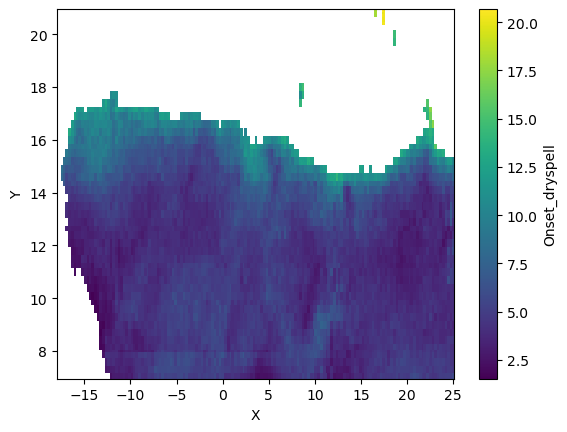

In [14]:
dryspellonset.mean(dim='T').plot()

#### Process dryspellonset in combining with Ground-Observation

In [15]:
# ## Path to the CPT file
# cpt_input_file_path = "./Observation/MAM_1991-2023_.txt"

In [16]:
## Read CSV
# df = pd.read_csv(cpt_input_file_path, na_values=-999.0, sep='\t')
# df_filtered = df[(df['STATION'] == 'LAT') | (df['STATION'] == 'LON') | 
#                  (pd.to_numeric(df['STATION'], errors='coerce').between(year_start, year_end))]

In [17]:
## Instantiate WAS_Merging class
# data_merger = WAS_Merging(dryspellonset_df, dryspellonset, date_month_day= '02-01')
# dryspellonset__, _ = data_merger.simple_bias_adjustment(do_cross_validation=False)

In [18]:
# data_merger.plot_merging_comparaison(dryspellonset_df, dryspellonset , dryspellonset__)

In [19]:
# dryspellonset = dryspellonset__

# 1st - Approach: Choice of Best Dynamical models and weighted Average

In [46]:
# Filter model names to identify precipitation-related models
#'UKMO_603.PRCP', 
center_variable = ['ECMWF_51.PRCP', 'METEOFRANCE_8.PRCP',
                   #'UKMO_603.PRCP', # Comment this line if your initialization month starts with March
                   'UKMO_604.PRCP',  # Comment this line if your initialization month starts before April
                   'DWD_21.PRCP', # Comment this line if your initialization month starts with March
                   'DWD_22.PRCP', # Comment this line if your initialization month starts before March
                   'CMCC_35.PRCP', 'ECCC_4.PRCP', 'ECCC_5.PRCP', 'JMA_3.PRCP', 'NCEP_2.PRCP'] 


# Specify the directory to save downloaded model data
dir_to_save_model = f"{dir_s2s}/daily_model_data"

# Define the month for model initialization (June)
month_of_initialization = "03"
day_of_initialization ="01"

# Define lead times corresponding to seasonal forecast targets
leadtime_hour = [str(i) for i in range(24, 5161, 24)] 

# Define the hindcast period for model data (years 1993 to 2016)
year_start_model = 1993
year_end_model = 2016

# Set the bounding box for the area of interest (latitude and longitude bounds)
extent_obs = [21, -18, 7, 25]  # [Northern, Western, Southern and Eastern] 

# Define if you want to download forecast or hindcast
forecast = None
ensemble_mean = 'mean',
# Specify whether to overwrite existing files when downloading data
force_download = False

In [47]:
file_path_hdcst = downloader.WAS_Download_Models_Daily(dir_to_save_model,center_variable,month_of_initialization, day_of_initialization, leadtime_hour, year_start_model, year_end_model, extent_obs, forecast, ensemble_mean, force_download,)

Agro_PRESASS_2025/daily_model_data/hindcast_ecmwf51_PRCP_Mar01_1993_2016_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/hindcast_meteo_france8_PRCP_Mar01_1993_2016_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/hindcast_ukmo604_PRCP_Mar01_1993_2016_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/hindcast_dwd21_PRCP_Mar01_1993_2016_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/hindcast_dwd22_PRCP_Mar01_1993_2016_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/hindcast_cmcc35_PRCP_Mar01_1993_2016_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/hindcast_eccc4_PRCP_Mar01_1993_2016_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/hindcast_eccc5_PRCP_Mar01_1993_2016_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/hindcast_jma3_PR

In [48]:
forecast = 2025

In [49]:
file_path_fcst = downloader.WAS_Download_Models_Daily(dir_to_save_model,center_variable,month_of_initialization, day_of_initialization, leadtime_hour, year_start_model, year_end_model, extent_obs, forecast, ensemble_mean, force_download,)

Agro_PRESASS_2025/daily_model_data/forecast_ecmwf51_PRCP_Mar01_2025_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/forecast_meteo_france8_PRCP_Mar01_2025_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/forecast_ukmo604_PRCP_Mar01_2025_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/forecast_dwd21_PRCP_Mar01_2025_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/forecast_dwd22_PRCP_Mar01_2025_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/forecast_cmcc35_PRCP_Mar01_2025_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/forecast_eccc4_PRCP_Mar01_2025_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/forecast_eccc5_PRCP_Mar01_2025_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/forecast_jma3_PRCP_Mar01_2025_24-5160.nc already exists.

In [50]:
hindcast_files, forecast_files = process_model_for_other_params(was_dryspellonset, dir_s2s, file_path_hdcst, file_path_fcst, rainfall, 
rainfall_for_forecast_year, month_of_initialization, year_start_model, year_end_model, forecast, nb_cores=2, agrometparam=agrometparam)

[SKIP] Agro_PRESASS_2025/model_data/hindcast_ecmwf51_dryspellonset_MarIc.nc already exists.
[SKIP] Agro_PRESASS_2025/model_data/hindcast_meteo_france8_dryspellonset_MarIc.nc already exists.
[SKIP] Agro_PRESASS_2025/model_data/hindcast_ukmo604_dryspellonset_MarIc.nc already exists.
[SKIP] Agro_PRESASS_2025/model_data/hindcast_dwd21_dryspellonset_MarIc.nc already exists.
[SKIP] Agro_PRESASS_2025/model_data/hindcast_dwd22_dryspellonset_MarIc.nc already exists.
[SKIP] Agro_PRESASS_2025/model_data/hindcast_cmcc35_dryspellonset_MarIc.nc already exists.
[SKIP] Agro_PRESASS_2025/model_data/hindcast_eccc4_dryspellonset_MarIc.nc already exists.
[SKIP] Agro_PRESASS_2025/model_data/hindcast_eccc5_dryspellonset_MarIc.nc already exists.
[SKIP] Agro_PRESASS_2025/model_data/hindcast_jma3_dryspellonset_MarIc.nc already exists.
[SKIP] Agro_PRESASS_2025/model_data/hindcast_ncep2_dryspellonset_MarIc.nc already exists.
[SKIP] Agro_PRESASS_2025/model_data/forecast_ecmwf51_dryspellonset_MarIc.nc already exis

In [51]:
was_verify = WAS_Verification(dist_method=dist_method)

#### Validation of GCM

In [52]:
score = ["Pearson", "MAE", "GROC"]

Pearson Correlation


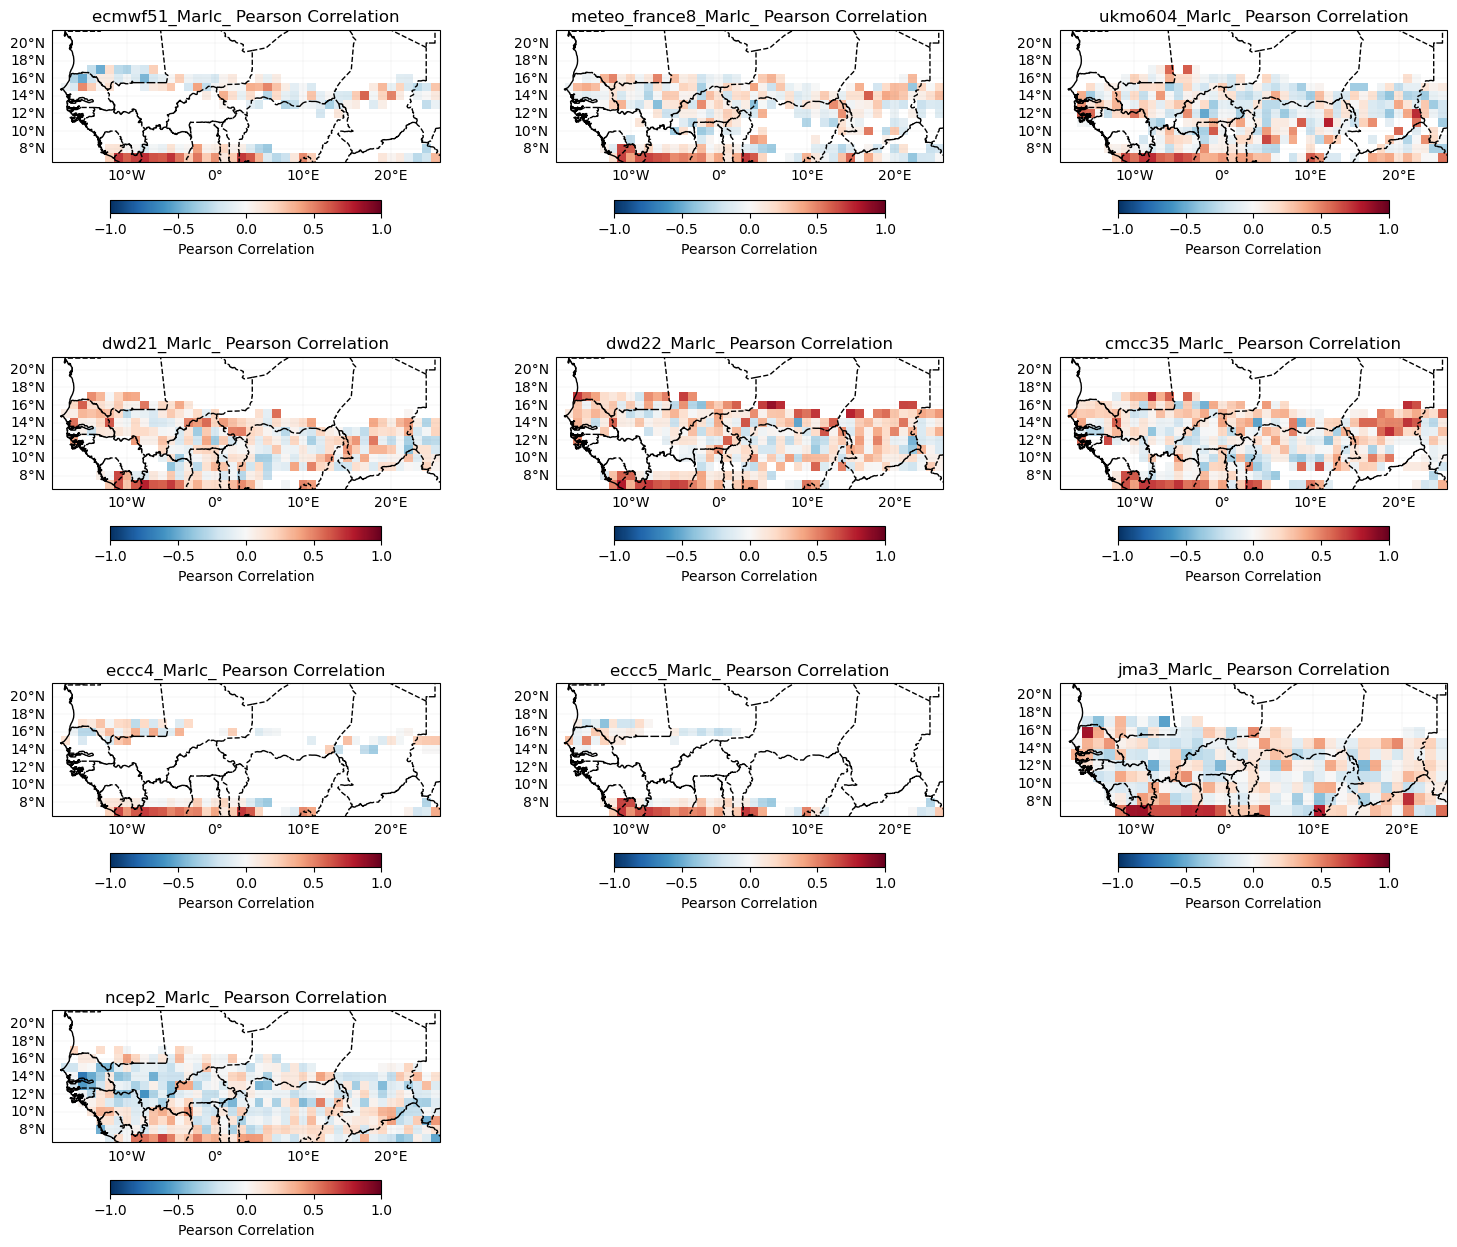

Mean Absolute Error


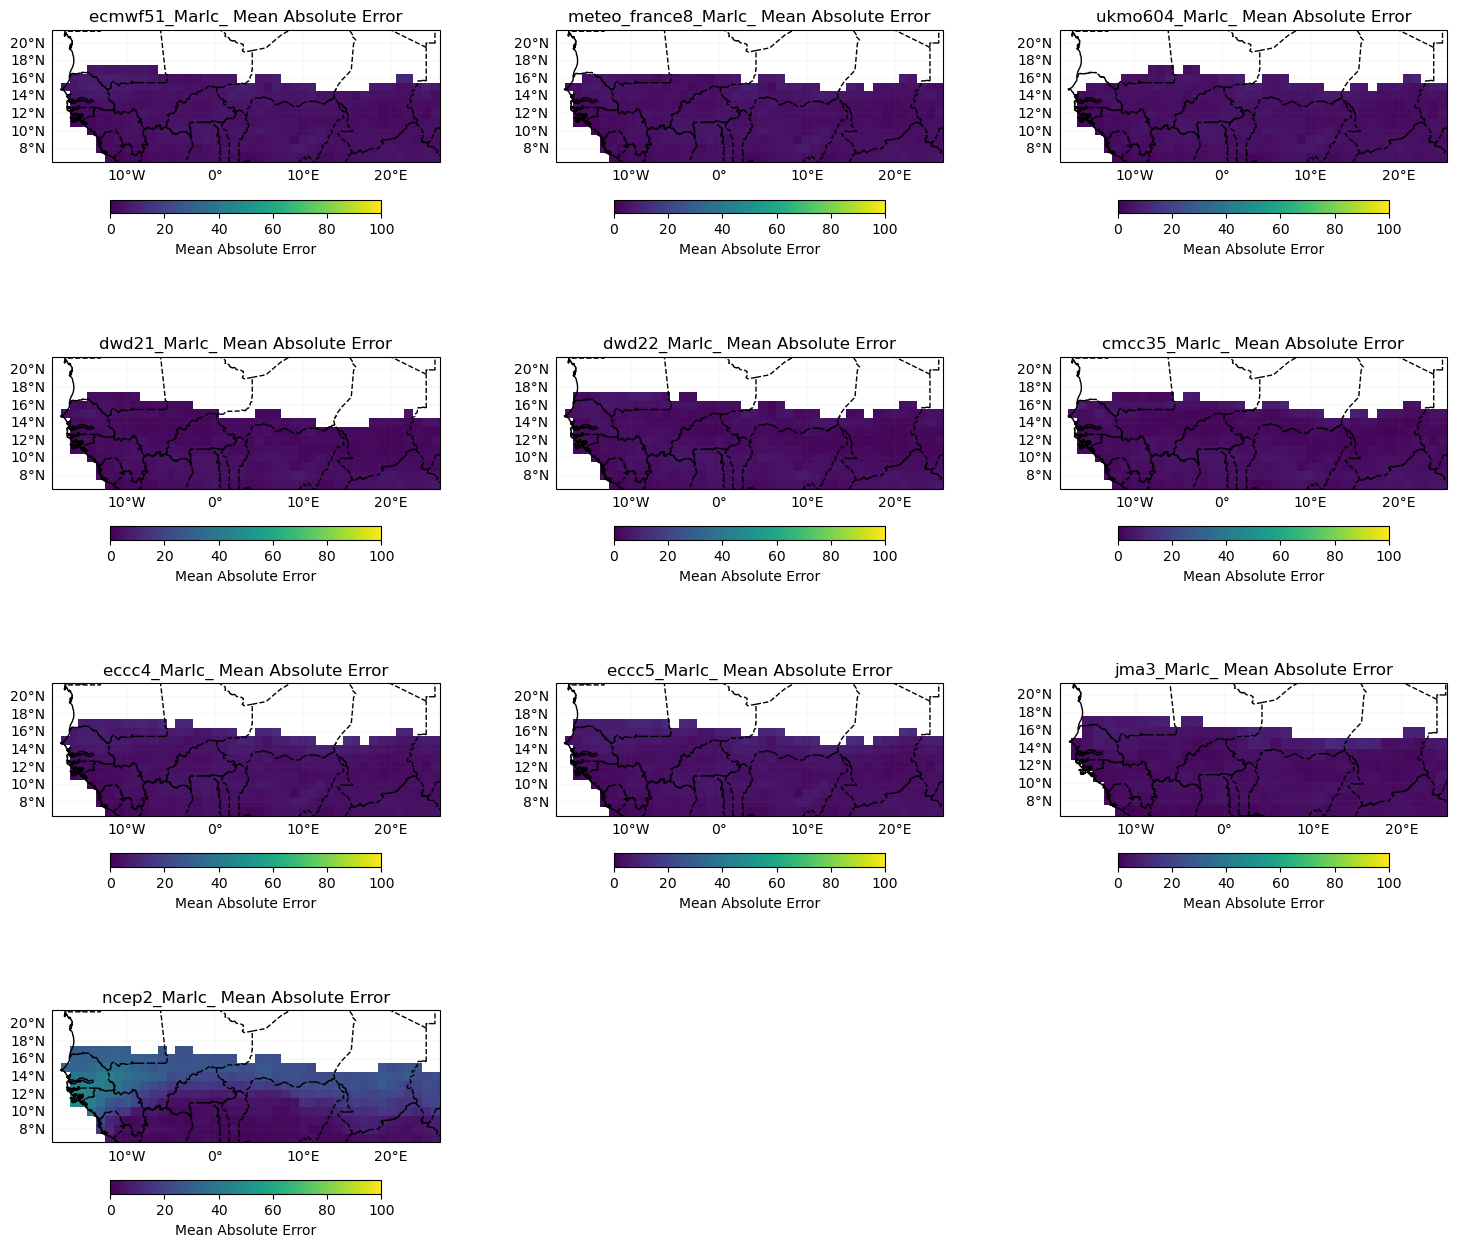

Generalized Discrimination Score


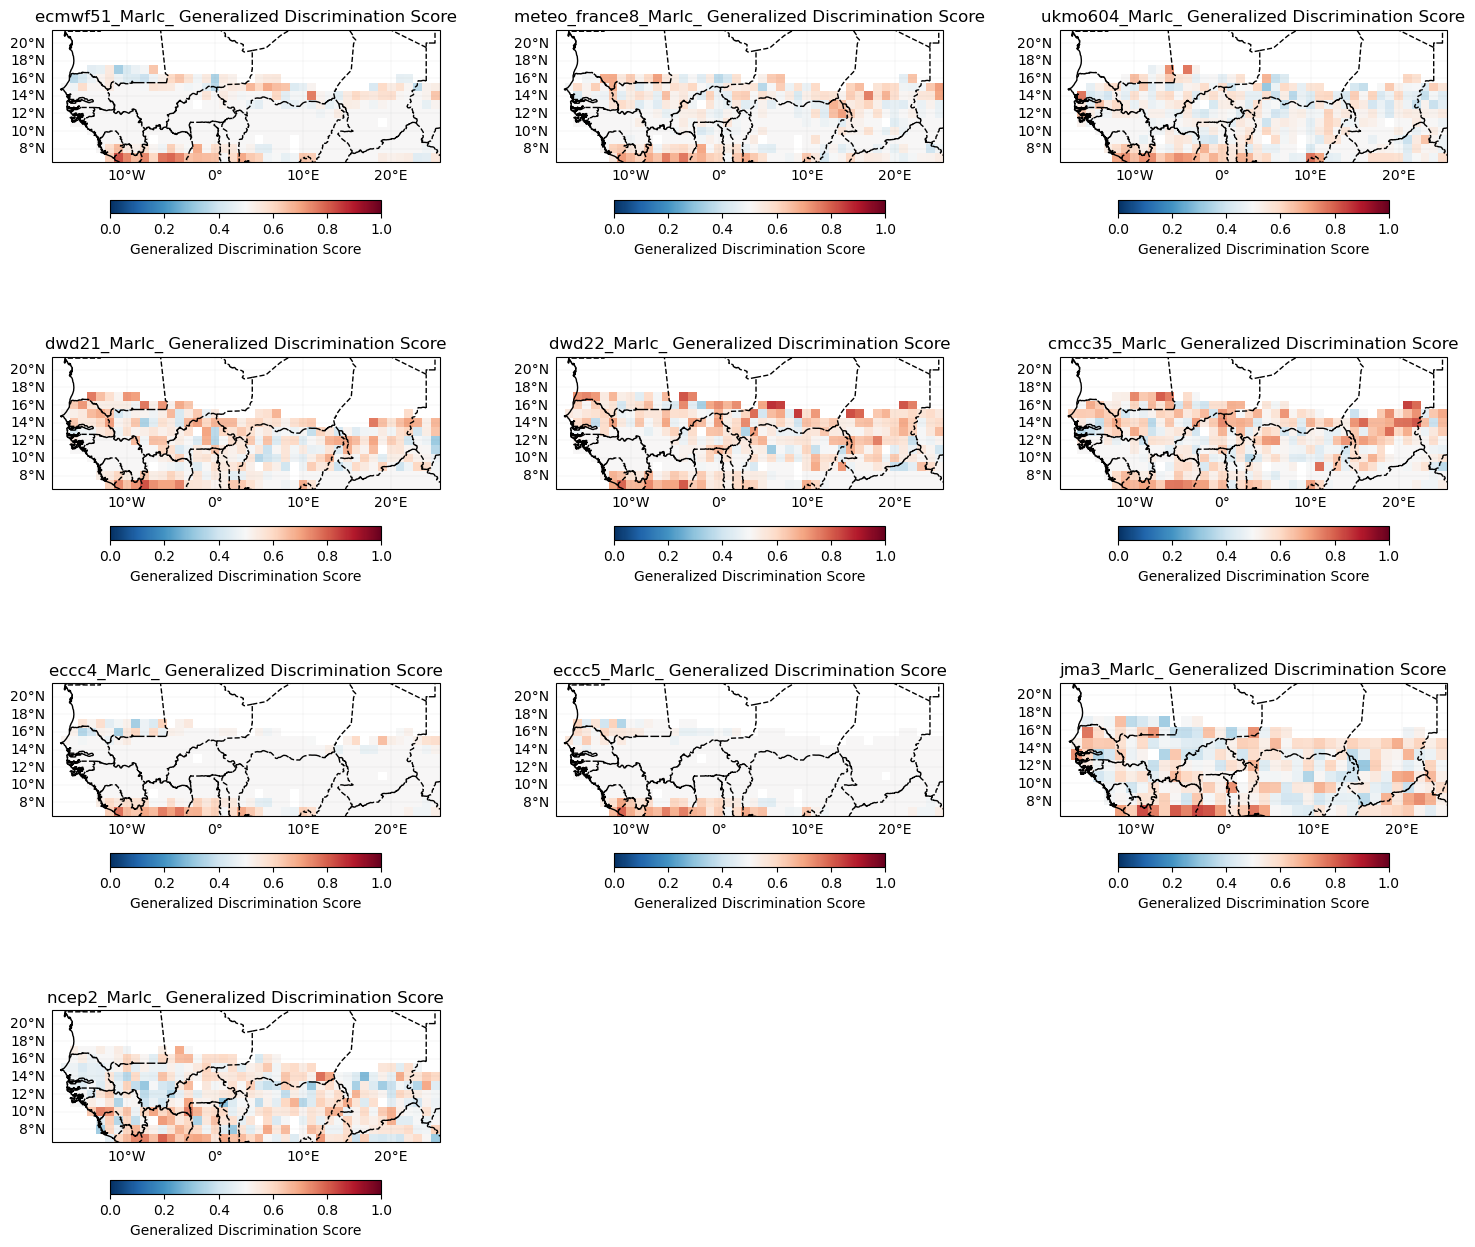

In [53]:
score = score.append('GROC') if 'GROC' not in score else score
os.makedirs(dir_save_score, exist_ok=True)
scores = {}
for i in score:
    scores[i] = was_verify.gcm_validation_compute(hindcast_files, dryspellonset, i, month_of_initialization, clim_year_start, clim_year_end, dir_save_score, lead_time = None, ensemble_mean=None, gridded=True)
    print(was_verify.scores[i][0])
    was_verify.plot_models_score(scores[i], i, dir_save_score)

## Choice of best GCM models

In [54]:
best_models = get_best_models(center_variable, scores, metric='GROC', threshold=0.5, top_n=4, agroparam=True, gcm=False)
best_models

['DWD_22.PRCP', 'NCEP_2.PRCP', 'CMCC_35.PRCP', 'DWD_21.PRCP']

## MME for best GCM models

In [55]:
n_estimators=10
learning_rate=0.1
max_depth=5
random_state=42
dist_method=dist_method

In [56]:
model = WAS_mme_XGBoosting(n_estimators=n_estimators,
                    learning_rate=learning_rate,
                    max_depth=max_depth,
                    random_state=random_state,
                    dist_method=dist_method)

#### Cross-validation

In [57]:
all_model_hdcst, all_model_fcst, obs, best_score = process_datasets_for_mme(dryspellonset.sel(T=slice(str(year_start_model),str(year_end_model))), hdcsted=hindcast_files, fcsted=forecast_files, scores= scores, gcm=False, agroparam=True, ELM_ELR=False, best_models=best_models)

In [58]:
was_mme_gcm = WAS_Cross_Validator(n_splits=len(dryspellonset.sel(T=slice(str(year_start_model),str(year_end_model))).get_index("T")), nb_omit=2)

In [33]:
hindcast_det_gcm, hindcast_prob_gcm, = was_mme_gcm.cross_validate(model, obs, all_model_hdcst, clim_year_start, clim_year_end)
hdcst_consolidated['first.approach'] = hindcast_det_gcm

Cross-validation ongoing


100%|███████████████████████████████████████████| 24/24 [00:13<00:00,  1.83it/s]


#### Verification

In [34]:
score = ['Pearson','MAE']
model_name = "MME_best_GCM_Models"

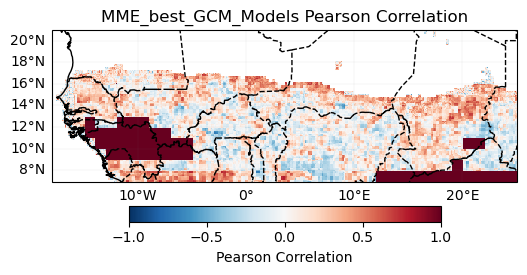

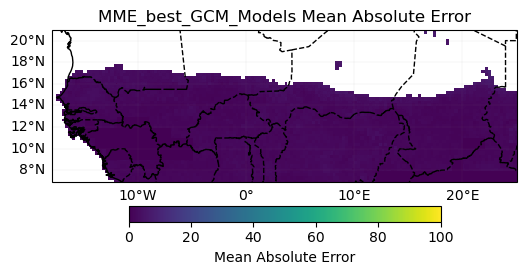

In [35]:
for i in score:
    r = was_verify.compute_deterministic_score(
        was_verify.get_scores_metadata()[i][5],
        dryspellonset.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_det_gcm
    )
    scores_consolidated[i] = {'first.approach': r}
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

##### Probabilistic

In [36]:
score = ['GROC']

Generalized Discrimination Score


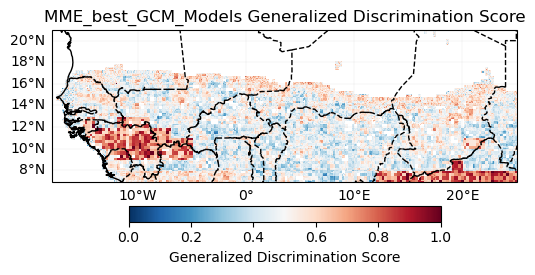

In [37]:
score = score.append('GROC') if 'GROC' not in score else score
for i in score:
    print(was_verify.scores[i][0])
    r = was_verify.compute_probabilistic_score(
        was_verify.get_scores_metadata()[i][5],
        dryspellonset.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_prob_gcm,
        clim_year_start,
        clim_year_end)
    scores_consolidated[i] = {'first.approach': r}
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

#### Forecast 

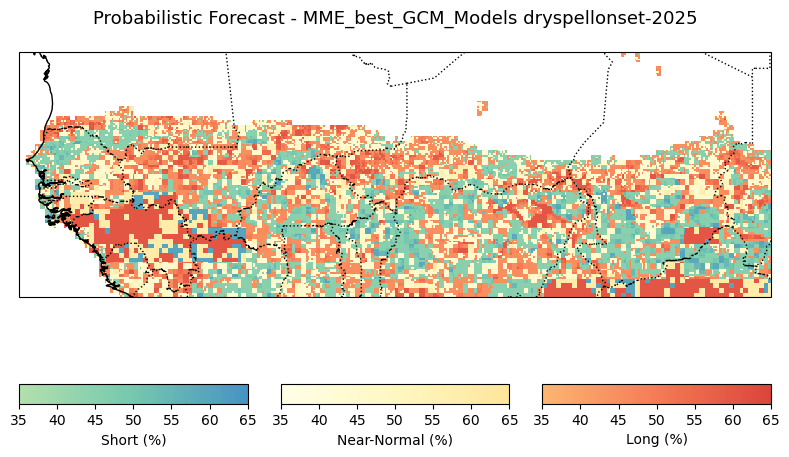

67701

In [38]:
forecast_det_gcm, forecast_prob_gcm= model.forecast(obs, clim_year_start, clim_year_end, all_model_hdcst, hindcast_det_gcm, all_model_fcst)
fcst_consolidated['first.approach'] = forecast_det_gcm
plot_prob_forecasts(dir_to_forecast, forecast_prob_gcm.drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast}", reverse_cmap=True, labels=fcst_labels)
gc.collect()

# 2nd - Approach: Statistico-Dynamical

In [66]:
# Filter model names to identify precipitation-related models
center_variable = [key for key in downloader.ModelsName().keys() if "PRCP" in key]


# center_variable = [key for key in downloader.ModelsName().keys() if "VGRD_850" in key]
center_variable.remove('UKMO_603.PRCP')


# Specify the directory to save downloaded model data
dir_to_save_model = f"{dir_s2s}/model_data"

# Define the month for model initialization (June)
month_of_initialization = "03"

# Define lead times corresponding to seasonal forecast targets (JAS season in this case)
lead_time = ["03", "04", "05"]  # July-August-September forecast period

# Define the hindcast period for model data (years 1993 to 2016)
year_start_model = 1993
year_end_model = 2016

# Set the bounding box for the area of interest (latitude and longitude bounds)
extent = [30, -30, 0, 30] #[60, -180, -60, 180]  # [Northern, Western, Southern and Eastern] 

# Define if you want to download forecast or hindcast
forecast = None

# Define if you want all members of ensemble or doing an ensemble mean
ensemble_mean = "mean"

# Specify whether to overwrite existing files when downloading data
force_download = False

In [67]:
hindcast_files = downloader.WAS_Download_Models(
    dir_to_save_model,
    center_variable,
    month_of_initialization,
    lead_time,
    year_start_model,
    year_end_model,
    extent, 
    forecast,
    ensemble_mean,
    force_download)

Agro_PRESASS_2025/model_data/hindcast_ecmwf51_PRCP_MarIc_JunJulAug_03.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/hindcast_ukmo604_PRCP_MarIc_JunJulAug_03.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/hindcast_meteofrance8_PRCP_MarIc_JunJulAug_03.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/hindcast_dwd21_PRCP_MarIc_JunJulAug_03.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/hindcast_dwd22_PRCP_MarIc_JunJulAug_03.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/hindcast_cmcc35_PRCP_MarIc_JunJulAug_03.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/hindcast_ncep2_PRCP_MarIc_JunJulAug_03.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/hindcast_jma3_PRCP_MarIc_JunJulAug_03.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/hindcast_eccc4_PRCP_MarIc_JunJulAug_03.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/hindca

In [68]:
forecast = 2025

In [69]:
forecast_files = downloader.WAS_Download_Models(
    dir_to_save_model,
    center_variable,
    month_of_initialization,
    lead_time,
    year_start_model,
    year_end_model,
    extent, 
    forecast,
    ensemble_mean,
    force_download)

Agro_PRESASS_2025/model_data/forecast_ecmwf51_PRCP_MarIc_JunJulAug_03.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/forecast_ukmo604_PRCP_MarIc_JunJulAug_03.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/forecast_meteofrance8_PRCP_MarIc_JunJulAug_03.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/forecast_dwd21_PRCP_MarIc_JunJulAug_03.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/forecast_dwd22_PRCP_MarIc_JunJulAug_03.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/forecast_cmcc35_PRCP_MarIc_JunJulAug_03.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/forecast_ncep2_PRCP_MarIc_JunJulAug_03.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/forecast_jma3_PRCP_MarIc_JunJulAug_03.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/forecast_eccc4_PRCP_MarIc_JunJulAug_03.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/foreca

### Initialize the WAS_CCA class (default)

In [ ]:
n_modes = 4
# define zone as dict : {'zone_name_key': ('Explicit_Zone_name', lon_min, lon_max, lat_min, lat_max)} 
defined_zone = {'A': ('A', -30, 30, 0, 30)} 

In [ ]:
plot_map([extent[1],extent[3],extent[2],extent[0]], sst_indices = defined_zone, title="Predictors Area",fig_size=(6,4))

##### Modes of CCA for each model

In [ ]:
was_cca = WAS_CCA(n_modes=n_modes, n_pca_modes=10, dist_method=dist_method)
was_cv = WAS_Cross_Validator(n_splits=len(dryspellonset.sel(T=slice(str(year_start_model),str(year_end_model))).get_index("T")), nb_omit=2)

In [ ]:
predictors = {}
for i in center_variable:
    predictors[i] = retrieve_single_zone_for_PCR(dir_to_save_model, defined_zone, i, year_start_model, year_end_model, clim_year_start=clim_year_start, clim_year_end=clim_year_end, model=True, month_of_initialization=month_of_initialization, lead_time=lead_time)
    predictor = predictors[i].isel(T = slice(None,-1))
    predictor['T'] = dryspellonset.sel(T=slice(str(year_start_model),str(year_end_model)))['T']
    print(f"CCA Modes for model {i}")
    was_cca.plot_cca_results(X=predictor, Y=dryspellonset.sel(T=slice(str(year_start_model),str(year_end_model))) , clim_year_start=clim_year_start, clim_year_end=clim_year_end)

#### Cross validation

In [ ]:
hindcast_det_dynam_all = {}
hindcast_prob_dynam_all = {}
for key, predictor in predictors.items():
    predictor = predictor.isel(T = slice(None,-1))
    predictor['T'] = dryspellonset.sel(T=slice(str(year_start_model),str(year_end_model)))['T']
    print(key.split(".")[0])
    hindcast_det_dynam_all[key], hindcast_prob_dynam_all[key] = was_cv.cross_validate(was_cca, dryspellonset.sel(T=slice(str(year_start_model),str(year_end_model))).sel(T=slice(str(year_start_model),str(year_end_model))), predictor, clim_year_start, clim_year_end)

#### Verification (individual)

###### Deterministic

In [ ]:
score = ['Pearson','MAE']
model_name = "CCA_2nd_Approch"

In [ ]:
cca_scores = {}
tmp = {}
for i in score:
    print(was_verify.scores[i][0])
    for key, hdcst in hindcast_det_dynam_all.items():
        tmp[key] = was_verify.compute_deterministic_score(
            was_verify.get_scores_metadata()[i][5],
            dryspellonset.sel(T=slice(str(year_start_model),str(year_end_model))),
            hindcast_det_dynam_all[key]
        )
        was_verify.plot_model_score(tmp[key], i, dir_save_score, f"{key}_{model_name}")
    cca_scores[i] = tmp

###### Probabilistic

In [ ]:
score = ['GROC']

In [ ]:
score = score.append('GROC') if 'GROC' not in score else score
tmp = {}
for i in score:
    print(was_verify.scores[i][0])
    for key, hdcst in hindcast_det_dynam_all.items():
        tmp[key] = was_verify.compute_probabilistic_score(
            was_verify.get_scores_metadata()[i][5],
            dryspellonset.sel(T=slice(str(year_start_model),str(year_end_model))),
            hindcast_prob_dynam_all[key],
            clim_year_start,
            clim_year_end)
        was_verify.plot_model_score(tmp[key], i, dir_save_score, f"{key}_{model_name}")
    cca_scores[i] = tmp

#### Forecast (individual)

In [ ]:
forecast_det_dynam_all = {}
forecast_prob_dynam_all = {}
for key, predictor in predictors.items():
    predictor_f = predictor.isel(T=[-1])
    predictor = predictor.isel(T = slice(None,-1))
    predictor['T'] = dryspellonset.sel(T=slice(str(year_start_model),str(year_end_model)))['T']
    print(key.split(".")[0])
    forecast_det_dynam_all[key], forecast_prob_dynam_all[key] = was_cca.forecast(dryspellonset.sel(T=slice(str(year_start_model),str(year_end_model))), clim_year_start, clim_year_end, predictor, hindcast_det_dynam_all[key], predictor_f)
    plot_prob_forecasts(dir_to_forecast, forecast_prob_dynam_all[key].drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast}", reverse_cmap=True, labels=fcst_labels)

### MME 2nd-Approach: Statistico-Dynamical

In [ ]:
#### Select some models
best_models = get_best_models(center_variable, cca_scores, metric='Pearson', threshold=0.2, top_n=8, gcm=False)
best_models

In [ ]:
was_2nd_mme = WAS_mme_Weighted(equal_weighted=False, dist_method=dist_method, metric="Pearson", threshold=0.5)

In [ ]:
all_model_hdcst, all_model_fcst, obs, best_score = process_datasets_for_mme(dryspellonset.sel(T=slice(str(year_start_model),str(year_end_model))),hdcsted=hindcast_det_dynam_all, fcsted=forecast_det_dynam_all, gcm=False, ELM_ELR=False,  best_models=best_models, scores=cca_scores, model=False)
hindcast_det_mme_2nd, forecast_det_mme_2nd  = was_2nd_mme.compute(obs, all_model_hdcst, all_model_fcst, best_score, complete=True)
hindcast_prob_mme_2nd = was_2nd_mme.compute_prob(dryspellonset.sel(T=slice(str(year_start_model),str(year_end_model))), clim_year_start, clim_year_end, hindcast_det_mme_2nd)
hdcst_consolidated['snd.approach'] = hindcast_det_mme_2nd

#### Verification

###### Deterministic

In [ ]:
score = ['Pearson','MAE']
model_name = "MME_2nd_Approach"

In [ ]:
for i in score:
    r = was_verify.compute_deterministic_score(
        was_verify.get_scores_metadata()[i][5],
        dryspellonset.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_det_mme_2nd
    )
    scores_consolidated[i]['snd.approach'] = r
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

###### Probabilistic

In [ ]:
score = ['GROC']

In [ ]:
score = score.append('GROC') if 'GROC' not in score else score
for i in score:
    print(was_verify.scores[i][0])
    r = was_verify.compute_probabilistic_score(
        was_verify.get_scores_metadata()[i][5],
        dryspellonset.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_prob_mme_2nd,
        clim_year_start,
        clim_year_end)
    scores_consolidated[i]['snd.approach'] = r
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

#### Forecast 

In [ ]:
forecast_prob_mme_2nd = was_2nd_mme.forecast(dryspellonset.sel(T=slice(str(year_start_model),str(year_end_model))), clim_year_start, clim_year_end, hindcast_det_mme_2nd, forecast_det_mme_2nd)
fcst_consolidated['snd.approach'] = forecast_det_mme_2nd
plot_prob_forecasts(dir_to_forecast, forecast_prob_mme_2nd.drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast}", reverse_cmap=True, labels=fcst_labels)

# 3rd - Approach: Observational-based seasonal forecast

In [ ]:
# Filter model names to identify precipitation-related models
variables_reanalysis = ["NOAA.SST"] #[key for key in downloader.ReanalysisName().keys() if "SST" in key]# or "VGRD_850" in key]

# Specify the directory to save downloaded model data
dir_to_save_Reanalysis = f"{dir_s2s}/reanalysis_data/"

# choose sequence corresponding to seasonal forecast targets (JAS season in this case)
season = ["01","02","03"]  # July-August-September forecast period

# Define the observation period (years 1993 to 2016)
year_start = 1991
year_end = 2025

# Set the bounding box for the area of interest (latitude and longitude bounds)
extent = [60, -180, -60, 180]  # [Northern, Western, Southern and Eastern] 

# Specify whether to overwrite existing files when downloading data
force_download = False

In [ ]:
downloader.WAS_Download_Reanalysis(
    dir_to_save_Reanalysis,
    variables_reanalysis,
    year_start,
    year_end,
    extent,
    season, 
    force_download
)

##### Process SST index 

In [ ]:
# Print available SST index
print(list(sst_indices_name.keys()))

In [ ]:
## Choose yours
sst_index_name = ['NINO34','TNA','TSA', 'DMI'] 

# Set your own indices zones ( zones not available in built-in)
my_own_indices_zone = {
                         #'A': ('A', -55, 10, -20, 25),
                         # 'B': ('B', -170, -80, -10, 10),
                         #'C': ('C', -10, 10, 1, 5),
                        }
others_zone = my_own_indices_zone

In [ ]:
# Combine all zones
sst_indices_all = {i: sst_indices_name[i] for i in sst_index_name} 
sst_indices_all.update(my_own_indices_zone) if my_own_indices_zone is not None else {i: sst_indices_name[i] for i in sst_index_name} 

In [ ]:
plot_map([extent[1],extent[3],extent[2],extent[0]], sst_indices = sst_indices_all, title="Index Zone",fig_size=(7,4))

In [ ]:
predictors = compute_sst_indices(dir_to_save_Reanalysis, sst_index_name, variables_reanalysis[0], year_start, year_end, season, clim_year_start, clim_year_end, my_own_indices_zone)

##### Calculate variance inflation factor to see multicolinearity predictor

In [ ]:
# Calculate VIF for each predictor
vif_data = pd.DataFrame()
vif_data["feature"] = predictors.to_dataframe().columns
vif_data["VIF"] = [VIF(predictors.to_dataframe(), i) for i in range(predictors.to_dataframe().shape[1])]
# Print VIF values
print(vif_data)

In [ ]:
# Set a threshold for VIF (e.g., 10)
vif_threshold = 5

In [ ]:
low_vif_predictors = vif_data[vif_data["VIF"] < vif_threshold]["feature"].tolist()
# Filter the predictors to exclude those with high VIF
filtered_predictors = predictors[low_vif_predictors].to_array()
filtered_predictors = filtered_predictors.rename({"variable": "features"}).transpose('T', 'features')
print(low_vif_predictors)

## Initialize WAS_LinearRegression_Model

In [ ]:
# Available core over machine
cpu_count()

In [ ]:
#### Set core number for computation
nb_cores = 4

In [ ]:
# Load class for model, cross-validation and verification
model = WAS_LinearRegression_Model(nb_cores = nb_cores, dist_method=dist_method)

#### Cross validation

In [ ]:
# Instantiate cross-validation
was_cv = WAS_Cross_Validator(n_splits=len(dryspellonset.isel(T = slice(None,-1)).get_index("T")), nb_omit=2)

In [ ]:
filtered_predictors_ = filtered_predictors.isel(T = slice(None,-1))
filtered_predictors_['T'] = dryspellonset['T']
hindcast_det_obs_seas_mlr, hindcast_prob_obs_seas_mlr = was_cv.cross_validate(model, dryspellonset, filtered_predictors_, clim_year_start, clim_year_end)

#### Verification

In [ ]:
score = ['Pearson','MAE']
model_name = "3rd-Approach-MLR"

###### Deterministic

In [ ]:
third_scores = {}
hindcast_det_obsBased_all = {}
for i in score:
    r = was_verify.compute_deterministic_score(
        was_verify.get_scores_metadata()[i][5],
        dryspellonset,
        hindcast_det_obs_seas_mlr
    )
    was_verify.plot_model_score(r, i, dir_save_score, model_name)
    third_scores[i] = {'third1.score': r}
hindcast_det_obsBased_all['third1.score'] = hindcast_det_obs_seas_mlr

###### Probabilistic

In [ ]:
score = ['GROC']

In [ ]:
score = score.append('GROC') if 'GROC' not in score else score
hindcast_prob_obsBased_all = {}
for i in score:
    print(was_verify.scores[i][0])
    r = was_verify.compute_probabilistic_score(
        was_verify.get_scores_metadata()[i][5],
        dryspellonset,
        hindcast_prob_obs_seas_mlr,
        clim_year_start,
        clim_year_end)
    was_verify.plot_model_score(r, i, dir_save_score, model_name)
    third_scores[i] = {'third1.score': r}
hindcast_prob_obsBased_all['third1.score'] = hindcast_prob_obs_seas_mlr

#### Forecast

In [ ]:
forecast_det_obsBased_all = {}
forecast_prob_obsBased_all = {}
f_predictors = filtered_predictors.isel(T=[-1])
f_predictors['T'] = forecast_det_gcm['T']
forecast_det_mlr, forecast_prob_mlr = model.forecast(dryspellonset, clim_year_start, clim_year_end, filtered_predictors_, hindcast_det_obs_seas_mlr, f_predictors)
forecast_det_obsBased_all['third1.score'] = forecast_det_mlr
forecast_prob_obsBased_all['third1.score'] = forecast_prob_mlr
plot_prob_forecasts(dir_to_forecast,forecast_prob_mlr.drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast}", reverse_cmap=True, labels=fcst_labels)

## Initialize Principal Component Regression with ElasticNet

##### Zone for EOFs  

In [ ]:
# Set your own zones ( zones not available in built-in)
# define zone as dict : {'zone_name_key': ('Explicit_Zone_name', lon_min, lon_max, lat_min, lat_max)} 
zones_for_PCR = {'A': ('A', -150, 150, -45, 45)}

# Set number of modes
n_modes=6

# ElasticNet hyperparameters range
alpha_range = np.logspace(-4, 0.1, 20)
l1_ratio_range = [0.8, 0.9, 0.95, 0.99]

In [ ]:
plot_map([extent[1],extent[3],extent[2],extent[0]], sst_indices = zones_for_PCR, title="Predictors Area",fig_size=(8,6))

In [ ]:
predictor = retrieve_single_zone_for_PCR(dir_to_save_Reanalysis, zones_for_PCR, variables_reanalysis[0], year_start, year_end, season, clim_year_start, clim_year_end)
# Load WAS_EOF Class, try in a cell WAS_EOF? to see all docstring about its methods
eof_model = WAS_EOF(n_modes=n_modes, use_coslat=True, standardize=True)
# Load predictor, compute EOFs and retrieve component, scores and explained variances
s_eofs, s_pcs, s_expvar, _ = eof_model.fit(predictor, dim="T",  clim_year_start=clim_year_start, clim_year_end=clim_year_end)
eof_model.plot_EOF(s_eofs, s_expvar)
gc.collect()

#### Cross-validation

In [ ]:
## Load class for model
regression_model = WAS_ElasticNet_Model(alpha_range = alpha_range, l1_ratio_range = l1_ratio_range, nb_cores = nb_cores, dist_method=dist_method)  # Initialize a linear model
pcr_model = WAS_PCR(regression_model=regression_model, n_modes=n_modes, standardize=False)

In [ ]:
# Compute alpha parameters
alpha, l1_ratio, clusters = regression_model.compute_hyperparameters(dryspellonset, s_pcs.isel(T=slice(None,-1)).rename({"mode": "features"}).transpose('T', 'features'))

In [ ]:
## Load class cross-validation
was_cv = WAS_Cross_Validator(n_splits=len(dryspellonset.get_index("T")), nb_omit=2)

In [ ]:
hindcast_det_ElasticNet, hindcast_prob_ElasticNet = was_cv.cross_validate(pcr_model, dryspellonset, predictor.isel(T=slice(None,-1)), clim_year_start, clim_year_end, alpha=alpha, l1_ratio=l1_ratio)

#### Verification

###### Deterministic

In [ ]:
score = ['Pearson','MAE']
model_name = "PCR with ElasticNet"

In [ ]:
for i in score:
    r = was_verify.compute_deterministic_score(
        was_verify.get_scores_metadata()[i][5],
        dryspellonset,
        hindcast_det_ElasticNet
    )
    was_verify.plot_model_score(r, i, dir_save_score, model_name)
    third_scores[i]['third2.score'] = r
hindcast_det_obsBased_all['third2.score'] = hindcast_det_ElasticNet

###### Probabilistic

In [ ]:
score = ['GROC']

In [ ]:
score = score.append('GROC') if 'GROC' not in score else score
for i in score:
    print(was_verify.scores[i][0])
    r = was_verify.compute_probabilistic_score(
        was_verify.get_scores_metadata()[i][5],
        dryspellonset,
        hindcast_prob_ElasticNet,
        clim_year_start,
        clim_year_end)
    was_verify.plot_model_score(r, i, dir_save_score, model_name)
    third_scores[i]['third2.score'] = r
hindcast_prob_obsBased_all['third2.score'] = hindcast_prob_ElasticNet

#### Forecast

In [ ]:
f_predictors = predictor.isel(T=[-1])
f_predictors['T'] = forecast_det_gcm['T']
forecast_det_ElasticNet, forecast_prob_ElasticNet = pcr_model.forecast(dryspellonset, clim_year_start, clim_year_end, predictor.isel(T=slice(None,-1)), hindcast_det_ElasticNet, f_predictors, alpha=alpha, l1_ratio=l1_ratio)       
forecast_det_obsBased_all['third2.score'] = forecast_det_ElasticNet
forecast_prob_obsBased_all['third2.score'] = forecast_prob_ElasticNet
plot_prob_forecasts(dir_to_forecast, forecast_prob_ElasticNet.drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast}", reverse_cmap=True, labels=fcst_labels)

### MME Third-Approach: Observational-based seasonal forecast

In [ ]:
#### Select some models
best_models = get_best_models(['third1.score','third2.score'], third_scores, metric='MAE', threshold=20, top_n=5, gcm=False)
best_models

In [ ]:
all_model_hdcst, all_model_fcst, obs, best_score = process_datasets_for_mme(dryspellonset, hdcsted=hindcast_det_obsBased_all, fcsted=forecast_det_obsBased_all, gcm=False, ELM_ELR=False,  best_models=best_models, scores=third_scores, model=False)

In [ ]:
was_3rd_mme = WAS_mme_BMA(obs, all_model_hdcst, all_model_fcst, dist_method=dist_method, alpha_=0.5, error_metric_="mae")
hindcast_det_mme_3rd  = was_3rd_mme.compute(draws=500, tune=1000, chains=2, verbose=False)
hindcast_prob_mme_3rd = was_3rd_mme.compute_prob(dryspellonset, clim_year_start, clim_year_end, hindcast_det_mme_3rd)
hdcst_consolidated['third.approach'] = hindcast_det_mme_3rd.sel(T=slice(str(year_start_model),str(year_end_model)))

#### Verification

###### Deterministic

In [ ]:
score = ['Pearson','MAE']
model_name = "MME_3rd_Approach"

In [ ]:
for i in score:
    r = was_verify.compute_deterministic_score(
        was_verify.get_scores_metadata()[i][5],
        dryspellonset,
        hindcast_det_mme_3rd
    )
    scores_consolidated[i]['third.approach'] = r
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

###### Probabilistic

In [ ]:
score = ['GROC']

In [ ]:
score = score.append('GROC') if 'GROC' not in score else score
for i in score:
    print(was_verify.scores[i][0])
    r = was_verify.compute_probabilistic_score(
        was_verify.get_scores_metadata()[i][5],
        dryspellonset,
        hindcast_prob_mme_3rd,
        clim_year_start,
        clim_year_end)
    scores_consolidated[i]['third.approach'] = r
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

#### Forecast

In [ ]:
forecast_det_mme_3rd, forecast_prob_mme_3rd = was_3rd_mme.forecast(obs, clim_year_start, clim_year_end, hindcast_det_mme_3rd)
fcst_consolidated['third.approach'] = forecast_det_mme_3rd
plot_prob_forecasts(dir_to_forecast, forecast_prob_mme_3rd.drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast}", reverse_cmap=True, labels=fcst_labels)
gc.collect()

# 4th - Analog-based seasonal forecast

## Initialize WAS_Analog class

In [ ]:
## Load class for model, cross-validation and verification
model = WAS_Analog(f"{dir_s2s}/analog", 
                    1990, 2025,"NOAA.SST", "NCEP_2.SST",
                    method_analog ="cor_based", 
                    month_of_initialization=3,
                    clim_year_start=clim_year_start, 
                    clim_year_end=clim_year_end,
                    define_extent = [-180, 180, -60, 60],
                    dist_method=dist_method
                    )

#### Cross-validation

In [ ]:
was_analog_cv = WAS_Cross_Validator(n_splits=len(dryspellonset.get_index("T")), nb_omit=2)

In [ ]:
hindcast_analog_det, hindcast_analog_prob = was_analog_cv.cross_validate(model, dryspellonset, clim_year_start=clim_year_start, clim_year_end=clim_year_end)
hdcst_consolidated['fourth.approach'] = hindcast_analog_det.sel(T=slice(str(year_start_model),str(year_end_model)))

#### Verification

###### Deterministic

In [ ]:
score = ['Pearson','MAE']
model_name = "analog_method"

In [ ]:
for i in score:
    r = was_verify.compute_deterministic_score(
        was_verify.get_scores_metadata()[i][5],
        dryspellonset,
        hindcast_analog_det
    )
    scores_consolidated[i]['fourth.approach'] = r
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

###### Probabilistic

In [ ]:
score = ['GROC']

In [ ]:
score = score.append('GROC') if 'GROC' not in score else score
for i in score:
    print(was_verify.scores[i][0])
    r = was_verify.compute_probabilistic_score(
        was_verify.get_scores_metadata()[i][5],
        dryspellonset,
        hindcast_analog_prob,
        clim_year_start,
        clim_year_end)
    scores_consolidated[i]['fourth.approach'] = r
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

#### Forecast

In [ ]:
ddd, similar_years, forecast_det_analog, forecast_prob_analog = model.forecast(dryspellonset, clim_year_start, clim_year_end, hindcast_analog_det, forecast)
fcst_consolidated['fourth.approach'] = forecast_det_analog
plot_prob_forecasts(dir_to_forecast, forecast_prob_analog.drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast}", reverse_cmap=True, labels=fcst_labels)

In [ ]:
## Analysis SST evolution
model.composite_plot(dryspellonset, clim_year_start, clim_year_end, hindcast_analog_det, plot_predictor=True)

# Consolidated Forecasts

In [ ]:
best_models = ["first.approach", 'snd.approach', 'third.approach', 'fourth.approach']

#### Cross-validation

In [ ]:
all_model_hdcst, all_model_fcst, obs, best_score = process_datasets_for_mme(dryspellonset.sel(T=slice(str(year_start_model),str(year_end_model))),hdcsted=hdcst_consolidated, fcsted=fcst_consolidated, gcm=False, ELM_ELR=False,  best_models=best_models, scores=scores_consolidated, model=False)

In [ ]:
was_mme = WAS_mme_Weighted(equal_weighted=False, dist_method=dist_method, metric="Pearson", threshold=0.5) 

In [ ]:
hindcast_det, forecast_det  = was_mme.compute(obs, all_model_hdcst, all_model_fcst, best_score, threshold=0.5, complete=False)
hindcast_prob = was_mme.compute_prob(dryspellonset.sel(T=slice(str(year_start_model),str(year_end_model))), clim_year_start, clim_year_end, hindcast_det)

#### Consolidated forecast Skill

In [ ]:
score = ['Pearson','MAE']
model_name = "Consolidated Forecast"

###### Deterministic

In [ ]:
for i in score:
    r = was_verify.compute_deterministic_score(
        was_verify.get_scores_metadata()[i][5],
        dryspellonset.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_det
    )
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

##### Probabilistic

In [ ]:
score = ['GROC']

In [ ]:
for i in score:
    print(was_verify.scores[i][0])
    r = was_verify.compute_probabilistic_score(
        was_verify.get_scores_metadata()[i][5],
        dryspellonset.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_prob,
        clim_year_start,
        clim_year_end) 
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

### Forecast 

In [ ]:
forecast_prob = was_mme.forecast(dryspellonset.sel(T=slice(str(year_start_model),str(year_end_model))), clim_year_start, clim_year_end, hindcast_det, forecast_det)
plot_prob_forecasts(dir_to_forecast, forecast_prob.drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast}", reverse_cmap=True, labels=fcst_labels)

#### Save Forecast for future evaluation

In [ ]:
forecast_det.to_netcdf(f'{dir_to_forecast}/Forecast_Det{season_str}_{forecast}.nc')

In [ ]:
forecast_prob.to_netcdf(f'{dir_to_forecast}/Forecast_Prob{season_str}_{forecast}.nc')

###       ------------------------------------------------------- END --------------------------------------------------

In [ ]:
!jupyter nbconvert --to html --no-input ./01_MME_dryspellonset.ipynb